In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
baseline = pd.read_csv('results/random_split.csv')
lower_lr_2 = pd.read_csv('results/random_split_1e-5_lr_2_epochs_results.csv')
lower_lr_3 = pd.read_csv('results/random_split_1e-5_lr_3_epochs_results.csv')
ewc_2 = pd.read_csv('results/random_split_ewc_10000_lambda_1e-5_lr_2_epochs_results.csv')
ewc_3 = pd.read_csv('results/random_split_ewc_10000000_lambda_1e-5_lr_3_epochs_results.csv')

In [30]:
experiments = []
tasks = []
accuracies = []

experiment_dict = {
    r'$\alpha = 10^{-3}$, 1 epoch': baseline,
    r'$\alpha = 10^{-5}$, 2 epochs': lower_lr_2,
    r'$\alpha = 10^{-5}$, 3 epochs': lower_lr_3,
    r'EWC w/ $\lambda = 10^4$, $\alpha = 10^{-5}$, 2 epochs': ewc_2,
    r'EWC w/ $\lambda = 10^7$, $\alpha = 10^{-5}$, 3 epochs': ewc_3
}

for name, df in experiment_dict.items():
    df = df.loc[2:3, ['EvaluationName', 'Accuracy']]
    df['EvaluationName'] = ['Task A', 'Task B']

    experiments.extend([name, name])
    tasks.extend(df['EvaluationName'])
    accuracies.extend(df['Accuracy'])

In [31]:
results_table = pd.DataFrame({
    "Experiment": experiments,
    "Task": tasks,
    "Accuracy": accuracies
})

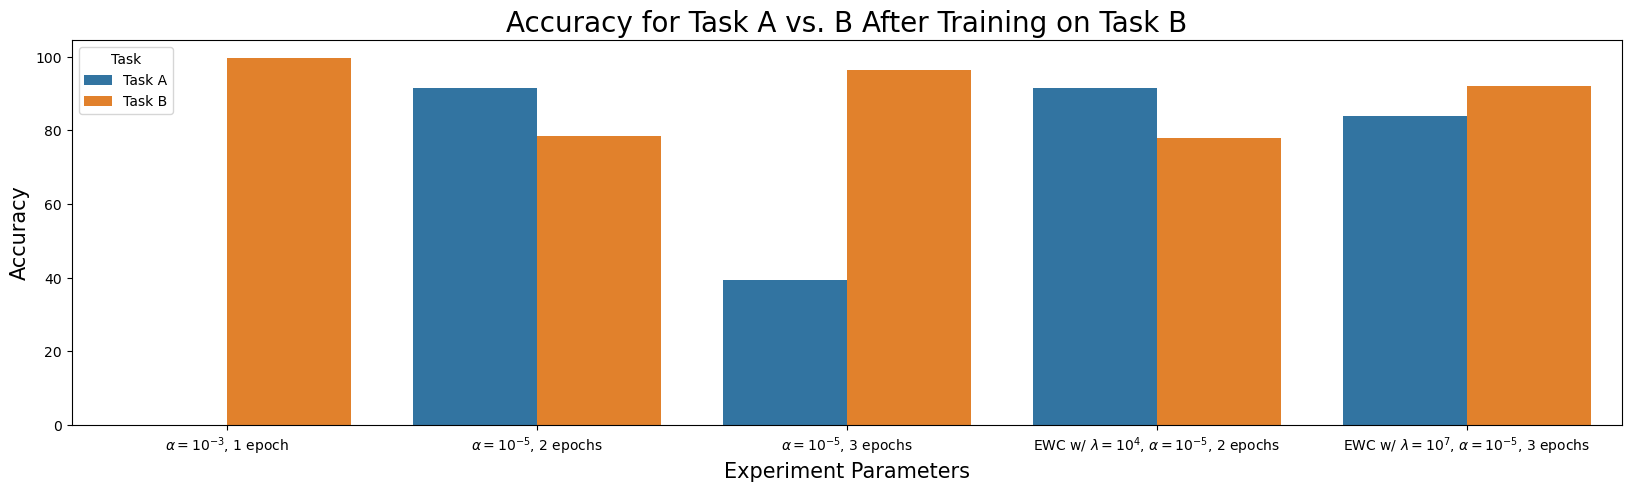

In [35]:
plt.figure(figsize=(20, 5))
sns.barplot(x='Experiment', y='Accuracy', hue='Task', data=results_table)
plt.xlabel('Experiment Parameters', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.title('Accuracy for Task A vs. B After Training on Task B', fontsize=20)
plt.show()